In [50]:
import pandas as pd

In [51]:
data = pd.read_csv("../data.csv")
data.head(3)


,text,sentiment
0,I love this product,positive
1,This is the worst thing ever,negative
2,It is okay not bad,neutral


In [52]:
X = data ["text"]
y = data["sentiment"]

In [53]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [56]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score




In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.0


In [58]:
sample = ["This product is really good"]
sample_vector = vectorizer.transform(sample)
prediction = model.predict(sample_vector)

In [59]:
print("Prediction:", prediction[0])

Prediction: neutral


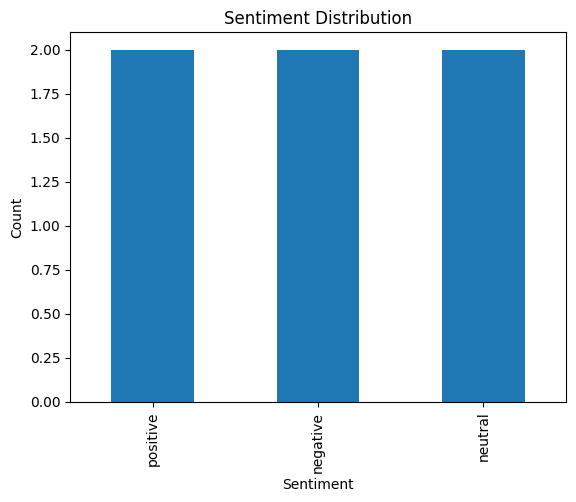

In [60]:
import matplotlib.pyplot as plt

data["sentiment"].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

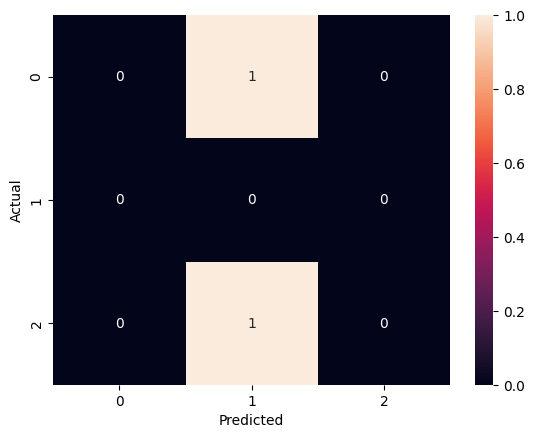

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
